# Dense Embeddings + 1D-CNN for Hate Speech Detection

This notebook upgrades the feature pipeline from sparse TF-IDF to dense word embeddings and uses a 1D-CNN to detect phrase-level semantic patterns.

## Why this upgrade?

- **Dense embeddings** (GloVe/Word2Vec-style vectors) reduce sparsity and encode semantic similarity.
- **1D-CNN** scans token sequences like n-gram pattern detectors, learning local semantic cues such as abusive phrase structures.

## Notebook-specific dependency note

This experiment requires deep-learning libraries that are intentionally not included in the shared project `requirements.txt` because the final submission pipeline does not depend on them.

Install them only when running this notebook:

```powershell
pip install \"tensorflow-cpu>=2.20,<2.22\" \"gensim>=4.3,<5.0\"
```

In [ ]:
%pip install "tensorflow-cpu>=2.20,<2.22" "gensim>=4.3,<5.0"

  Using cached tensorflow_cpu-2.21.0-cp311-cp311-win_amd64.whl.metadata (4.5 kB)
Using cached tensorflow_cpu-2.21.0-cp311-cp311-win_amd64.whl (350.8 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

sns.set_theme(style='whitegrid')


In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Resolve project root robustly whether notebook is launched from root, notebooks/, or notebooks/experiments/.
cwd = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / 'data').exists() and (candidate / 'requirements.txt').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError(f'Could not resolve project root from {cwd}. Open notebook from project workspace.')

CLEANED_DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'cleaned_labeled_data.csv'
GLOVE_PATH = PROJECT_ROOT / 'data' / 'embeddings' / 'glove.6B.100d.txt'  # Optional local file fallback
GLOVE_MODEL_NAME = 'glove-wiki-gigaword-100'

MAX_WORDS = 50000
MAX_LEN = 40
EMBEDDING_DIM = 100
BATCH_SIZE = 128
EPOCHS = 20

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'Preferred pre-trained source: {GLOVE_MODEL_NAME}')


PROJECT_ROOT: C:\Users\Atharva\OneDrive\Desktop\WebD\hate-speech-detection
Preferred pre-trained source: glove-wiki-gigaword-100


## Load data

In [4]:
if not CLEANED_DATA_PATH.exists():
    raise FileNotFoundError(
        f"{CLEANED_DATA_PATH} not found. Run preprocess_data.py first."
    )

df = pd.read_csv(CLEANED_DATA_PATH)
if "clean_tweet" not in df.columns or "class" not in df.columns:
    raise KeyError("Expected columns: 'clean_tweet' and 'class'")

df = df[["clean_tweet", "class"]].dropna()
df["clean_tweet"] = df["clean_tweet"].astype(str)
df["class"] = df["class"].astype(int)

print("Dataset shape:", df.shape)
print("Class distribution:")
print(df["class"].value_counts().sort_index())
display(df.head(3))

Dataset shape: (24781, 2)
Class distribution:
class
0     1430
1    19189
2     4162
Name: count, dtype: int64


,clean_tweet,class
0,as a woman you shouldn t complain about cleani...,2
1,boy dats cold tyga dwn bad for cuffin dat hoe ...,1
2,dawg you ever fuck a bitch and she start to cr...,1


## Train/Validation/Test split

In [5]:
X = df["clean_tweet"].to_numpy()
y = df["class"].to_numpy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))

Train: 19824 Val: 2478 Test: 2479


## Tokenize and pad sequences

In [6]:
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

train_seq = tokenizer.texts_to_sequences(X_train)
val_seq = tokenizer.texts_to_sequences(X_val)
test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad = pad_sequences(val_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print("Vocab size used:", vocab_size)
print("Padded input shape:", X_train_pad.shape)

Vocab size used: 17722
Padded input shape: (19824, 40)


## Load pre-trained GloVe embeddings

The notebook first tries gensim download (glove-wiki-gigaword-100).
If that fails (e.g., offline), it falls back to local data/embeddings/glove.6B.100d.txt.


In [7]:
embedding_matrix = None
used_pretrained = False
pretrained_source = None

# 1) Preferred: gensim downloader GloVe
try:
    import gensim.downloader as api
    print(f'Trying to load pre-trained vectors: {GLOVE_MODEL_NAME}')
    glove_vectors = api.load(GLOVE_MODEL_NAME)
    embedding_matrix = np.random.normal(scale=0.6, size=(vocab_size, EMBEDDING_DIM)).astype('float32')
    embedding_matrix[0] = np.zeros((EMBEDDING_DIM,), dtype='float32')

    hits = 0
    for word, idx in tokenizer.word_index.items():
        if idx >= vocab_size:
            continue
        if word in glove_vectors:
            embedding_matrix[idx] = glove_vectors[word]
            hits += 1

    used_pretrained = True
    pretrained_source = f'gensim:{GLOVE_MODEL_NAME}'
    print(f'Loaded {pretrained_source}')
    print(f'Tokenizer words matched: {hits}')

except Exception as e:
    print(f'Gensim GloVe load failed: {e}')

# 2) Fallback: local GloVe text file
if embedding_matrix is None and GLOVE_PATH.exists():
    embeddings_index = {}
    with GLOVE_PATH.open('r', encoding='utf-8') as f:
        for line in f:
            values = line.rstrip().split(' ')
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            if vector.shape[0] == EMBEDDING_DIM:
                embeddings_index[word] = vector

    embedding_matrix = np.random.normal(scale=0.6, size=(vocab_size, EMBEDDING_DIM)).astype('float32')
    embedding_matrix[0] = np.zeros((EMBEDDING_DIM,), dtype='float32')

    hits = 0
    for word, idx in tokenizer.word_index.items():
        if idx >= vocab_size:
            continue
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[idx] = vec
            hits += 1

    used_pretrained = True
    pretrained_source = f'local:{GLOVE_PATH.name}'
    print(f'Loaded {pretrained_source}')
    print(f'Tokenizer words matched: {hits}')

if embedding_matrix is None:
    raise RuntimeError(
        'Could not load pre-trained GloVe embeddings. '
        'Check internet for gensim download or place glove.6B.100d.txt in data/embeddings/.'
    )


Trying to load pre-trained vectors: glove-wiki-gigaword-100
Loaded gensim:glove-wiki-gigaword-100
Tokenizer words matched: 14134


## Build 1D-CNN model

In [8]:
if embedding_matrix is not None:
    embedding_layer = Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=True,
    )
else:
    embedding_layer = Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN,
        trainable=True,
    )

model = Sequential([
    embedding_layer,
    Conv1D(128, kernel_size=3, activation="relu"),
    Dropout(0.3),
    Conv1D(128, kernel_size=4, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(3, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

c:\Users\Atharva\OneDrive\Desktop\WebD\hate-speech-detection\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,772,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,772,200 (6.76 MB)

 Trainable params: 1,772,200 (6.76 MB)

 Non-trainable params: 0 (0.00 B)

## Train with class weights

In [9]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("class_weight:", class_weight)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
]

history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

class_weight: {0: 5.776223776223776, 1: 0.43046055631554947, 2: 1.984980474617002}
Epoch 1/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.6342 - loss: 0.8273 - val_accuracy: 0.8208 - val_loss: 0.5115 - learning_rate: 0.0010
Epoch 2/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7959 - loss: 0.5399 - val_accuracy: 0.8503 - val_loss: 0.4219 - learning_rate: 0.0010
Epoch 3/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8225 - loss: 0.4414 - val_accuracy: 0.8418 - val_loss: 0.3990 - learning_rate: 0.0010
Epoch 4/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8417 - loss: 0.3578 - val_accuracy: 0.8426 - val_loss: 0.4175 - learning_rate: 0.0010
Epoch 5/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8546 - loss: 0.2972 - val_accuracy: 0.8559 - val_loss: 0.3921 - learning_rate: 0.0010
Epoch 6/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8785 - loss: 0.2302 - val_accuracy: 0.8257 - val_loss: 0.4291 - learning_rate: 0.0010

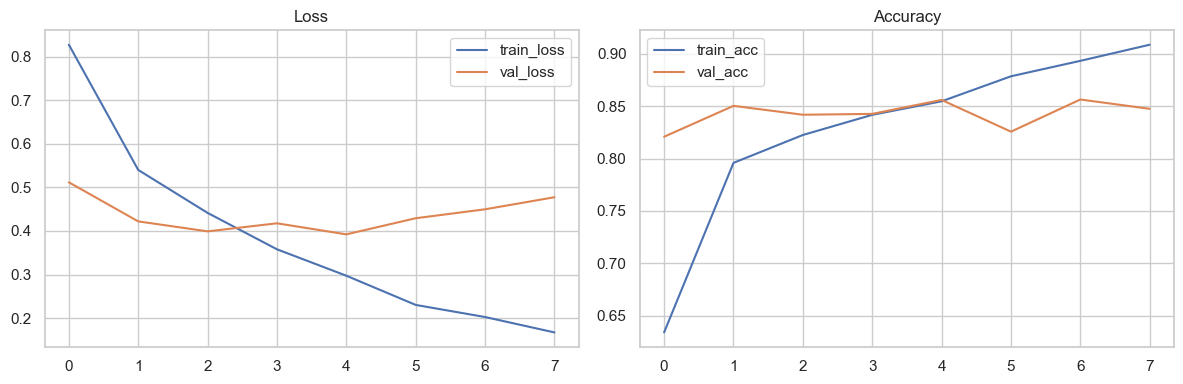

In [10]:
hist_df = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_df["loss"], label="train_loss")
axes[0].plot(hist_df["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(hist_df["accuracy"], label="train_acc")
axes[1].plot(hist_df["val_accuracy"], label="val_acc")
axes[1].set_title("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

## Evaluate on test set

In [11]:
test_probs = model.predict(X_test_pad)
y_pred = np.argmax(test_probs, axis=1)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
}

print("Used pretrained embeddings:", used_pretrained)
print("\nTest metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Used pretrained embeddings: True

Test metrics:
accuracy: 0.8608
precision_macro: 0.6979
recall_macro: 0.8113
f1_macro: 0.7349
f1_weighted: 0.8748

Classification report:
              precision    recall  f1-score   support

           0     0.3274    0.6434    0.4340       143
           1     0.9650    0.8624    0.9108      1919
           2     0.8012    0.9281    0.8600       417

    accuracy                         0.8608      2479
   macro avg     0.6979    0.8113    0.7349      2479
weighted avg     0.9007    0.8608    0.8748      2479



,pred_0,pred_1,pred_2
true_0,92,38,13
true_1,181,1655,83
true_2,8,22,387


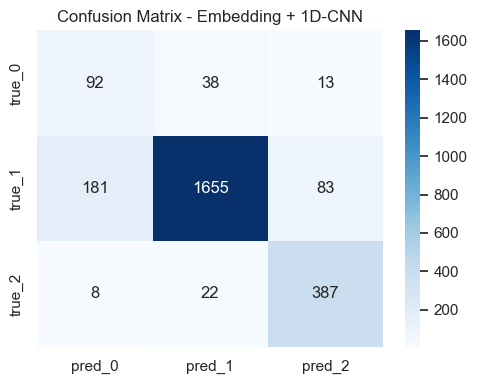

In [12]:
labels = np.sort(np.unique(y_test))
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"true_{i}" for i in labels], columns=[f"pred_{i}" for i in labels])
display(cm_df)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Embedding + 1D-CNN")
plt.tight_layout()
plt.show()